# Análisis de la morfología interna del fruto en Cranberry


In [1]:
# Session details
import traitly
from datetime import datetime

print(f"Traitly version used in this tutorial: {traitly.__version__}")
print(f"Run date: {datetime.now():%Y-%m-%d %H:%M}")  # 2026-10-05 14:30

Traitly version used in this tutorial: 0.2.0
Run date: 2026-10-05 12:56


En este tutorial, demostraremos cómo realizar el análisis de la morfología interna de frutos utilizando `FruitInternalAnalyzer`, una herramienta para extraer medidas de morfología y color a partir de una imagenes de rodajas transversales de cranberry.

El primer paso es cargar la clase `FruitInternalAnalyzer` desde Traitly para crear el objeto `cranberry`, que contendrá todo lo necesario para el análisis. Puedes elegir el nombre de objeto que prefieras.

A continuación, inicializamos la clase indicando la ubicación de nuestra imagen mediante el parámetro `path`.  

In [2]:
from traitly.fruit_phenotyping import FruitInternalAnalyzer

In [3]:
image_path = "./cranberry_slices.jpg"
cranberry = FruitInternalAnalyzer(path = image_path)

Primero, cargamos la imagen en el objeto mediante `load_image()`. Por defecto, la imagen se mostrará en pantalla (`plot=True`). Una vez cargada, puede accederse a ella a través de `cranberry.img`. Para más detalles sobre los datos almacenados en el objeto, consulta el apartado de [atributos de la clase].

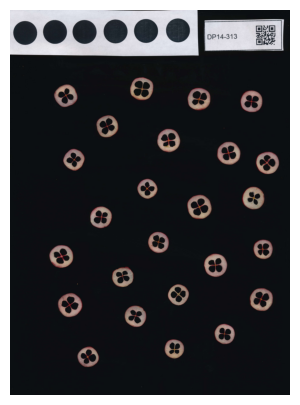

In [4]:
cranberry.load_image() 

A continuación, ejecutamos `setup_measurements()` para establecer el diámetro de las referencias de tamaño (círculos negros) y, opcionalmente, extraer la información del código QR de la etiqueta. Activando `plot = True` podemos inspeccionar en detalle la detección de la referencia y el diámetro en píxeles de cada círculo.

<br>

Como indican los resultados, se detectó una tira de círculos (`Ref 1`) compuesta por 6 círculos. Antes de calcular el promedio, `setup_measurements()` elimina los círculos cuya desviación estándar es mayor a 2, para evitar ruido por círculos mal detectados o muy diferentes al resto. En este caso, se usaron 5 de los 6 círculos para obtener un diámetro promedio de 218 px. Este valor se divide entre el diámetro real promedio en centímetros para obtener la densidad de píxeles por cm, que se usará para convertir píxeles a centímetros en análisis posteriores.


★ LABEL DETECTION:
> QR Code detected: DP14-313 (0.62s)

★ REFERENCE SIZE:
> Reference size detected:
  - Processing 1 box(es) with confidence >=0.6:
            Ref 1: 1904x297 px, conf: 0.821

  - Total circles detected: 6
            Circles used: 6/6 (std > 2)
            Mean diameter: 217.0 ± 1.0 px

        . ݁₊ ⊹ . ݁ ⟡ ݁ px/cm density: 127.6 (diameter_cm: 1.7 cm) ⟡ ݁ . ⊹ ₊ ݁.


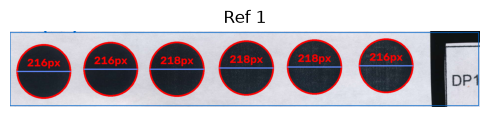

In [5]:
cranberry.setup_measurements(detect_label = True,
                            diameter_cm = 1.7, 
                            plot = True)

A continuación, generamos una máscara binaria de frutos y lóculos con `generate_fruit_mask()`, donde los lóculos aparecerán en negro y el resto del fruto en blanco.

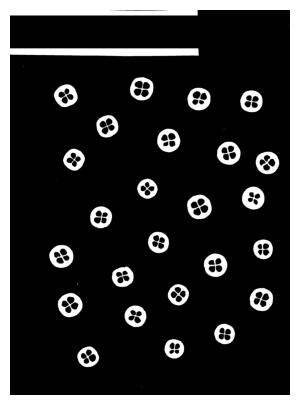

In [6]:
cranberry.generate_fruit_mask()

Después, detectamos los frutos en la máscara con `detect_fruits()` y hacemos una inspección rápida con `plot=True`. La imagen muestra para cada fruto su contorno en verde, los contornos de sus lóculos en rosa y el área del pericarpio interno en cyan. Esta visualización permite corroborar la detección y determinar si es necesario ajustar los parámetros de segmentación.


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 25 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.5
        - min_locule_area: 50
        - min_locule_per_fruit: 1
        - min_fruit_area: 1000


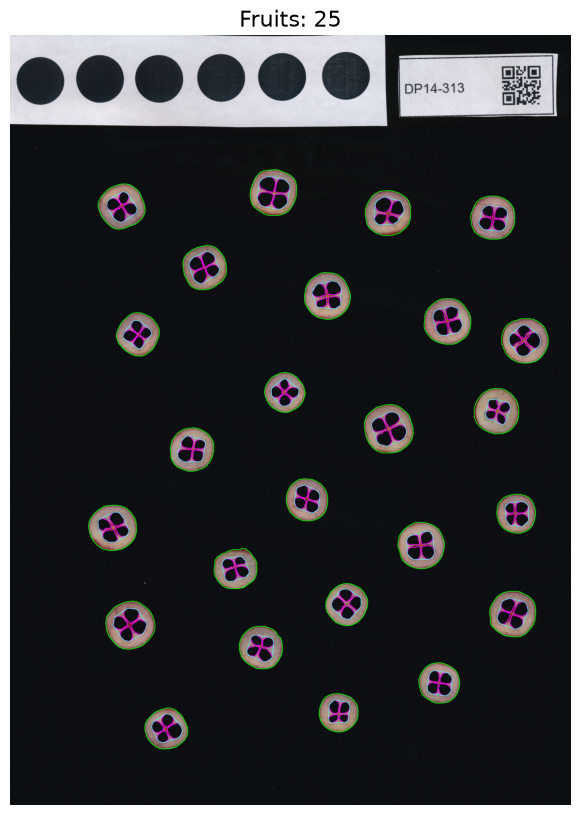

In [7]:
cranberry.detect_fruits(plot = True,
                       plot_size = (10,10))

Ahora, llevamos a cabo el analisis morfológico con `analyze_morphology`, el cual genera una copia de la imagen original con anotaciones para cada fruto y un DataFrame con los resultados. En ambos archivos, cada fruto es asignado a un identificador único (`id`) el cual es útil para comparar visualizar los datos numéricos.

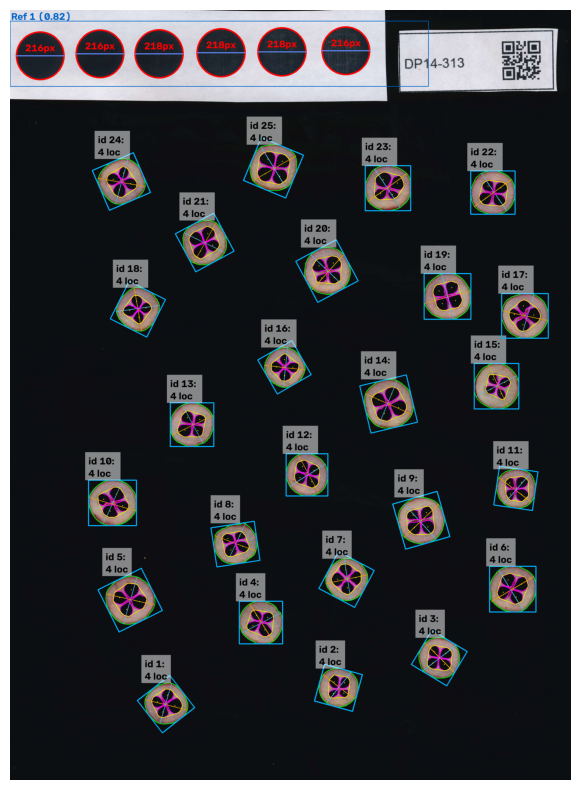

,image_name,label,fruit_id,n_locules,unit,fruit_area_cm2,fruit_perimeter_cm,fruit_circularity,fruit_solidity,fruit_convexity,...,locules_std_circularity,locules_cv_circularity,locules_angular_symmetry,locules_radial_symmetry,outer_pericarp_to_fruit_ratio,internal_pericarp_to_fruit_ratio,internal_pericarp_to_total_internal_ratio,locules_total_area_cm2,locules_to_fruit_ratio,locules_to_total_internal_ratio
0,cranberry_slices.jpg,DP14-313,1,4,cm,1.704547,5.042911,0.842280,0.988715,0.927457,...,0.051470,7.140915,0.073770,1.896778,0.549319,0.098637,0.218862,0.600076,0.352044,0.781138
1,cranberry_slices.jpg,DP14-313,2,4,cm,1.505422,4.760557,0.834742,0.987420,0.921867,...,0.042956,6.274469,0.088394,4.099928,0.644013,0.096009,0.269698,0.391377,0.259978,0.730302
2,cranberry_slices.jpg,DP14-313,3,4,cm,1.652257,4.993680,0.832619,0.988616,0.920782,...,0.028622,3.709216,0.024739,1.674191,0.605464,0.077392,0.196159,0.524004,0.317144,0.803841
3,cranberry_slices.jpg,DP14-313,4,4,cm,1.848590,5.251974,0.842181,0.988546,0.925857,...,0.059414,7.825871,0.085427,2.977507,0.622948,0.101924,0.270318,0.508599,0.275128,0.729682
4,cranberry_slices.jpg,DP14-313,5,4,cm,2.301094,5.867488,0.839924,0.988831,0.924711,...,0.038800,5.200966,0.075449,4.895965,0.576820,0.099777,0.235780,0.744180,0.323403,0.764220
5,cranberry_slices.jpg,DP14-313,6,4,cm,2.148490,5.790396,0.805242,0.986585,0.907714,...,0.019209,2.547710,0.070909,6.159125,0.583926,0.096581,0.232124,0.686428,0.319493,0.767876
6,cranberry_slices.jpg,DP14-313,7,4,cm,1.707738,5.104009,0.823774,0.987263,0.916677,...,0.028031,4.020832,0.056594,5.985664,0.540080,0.100070,0.217582,0.614529,0.359850,0.782418
7,cranberry_slices.jpg,DP14-313,8,4,cm,1.742752,5.247385,0.795352,0.982850,0.907571,...,0.036651,5.515499,0.088002,8.107052,0.623891,0.089942,0.239139,0.498718,0.286167,0.760861
8,cranberry_slices.jpg,DP14-313,9,4,cm,2.164600,5.887419,0.784761,0.986642,0.894509,...,0.029433,3.892335,0.079436,1.801348,0.613802,0.097662,0.252882,0.624564,0.288535,0.747118
9,cranberry_slices.jpg,DP14-313,10,4,cm,2.181877,5.726148,0.836209,0.989355,0.922177,...,0.051658,7.080627,0.046856,5.909857,0.613105,0.097114,0.251009,0.632266,0.289781,0.748991


In [8]:
cranberry.analyze_morphology()

Alternativamente podemos explorar a detalle la segmentación de los diferentes tejidos de un fruto con `generate_single_fruit_masks`. Mediante el parámetro `fruit_id` podemos indicar exactamente cual fruto de la imagen o la tabla queremos visualizar. 

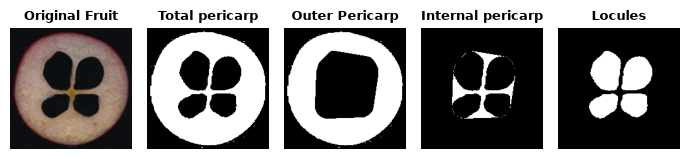

In [9]:
cranberry.generate_single_fruit_masks(fruit_id = 2)

Finalmente, analizaremos el color de cada fruto. Por default, `analyze_color()` extrae información de color en los canales `rgb`, `lab`, `hsv` y `gray` para los tejidos `total_pericarp`, `outer_pericarp`, `internal_pericarp` y `locules`.

En este caso, excluiremos los lóculos del análisis, ya que al estar huecos, solo capturan el color negro del fondo. Para seleccionar tejidos específicos utilizamos el parámetro `tissue`, y para seleccionar canales de color específicos utilizamos el parámetro `color_space`.

Al pasar múltiples valores, estos deben escribirse separados por comas, en minúsculas y con los espacios reemplazados por `_`. Por ejemplo:

- Canales RGB y HSV: `rgb, hsv`
- Tejidos lóculos, pericarpio total y pericarpio externo: `locules, total_pericarp, outer_pericarp`

Si necesitamos mayor control sobre qué tejidos analizar, las máscaras obtenidas con `generate_single_fruit_masks()` nos permiten seleccionar únicamente los tejidos más relevantes para el análisis.

In [10]:
tissues_ext = 'total_pericarp, outer_pericarp, internal_pericarp'

cranberry.analyze_color(tissue = tissues_ext,
                       color_space = 'rgb')

,image_name,label,fruit_id,tissue,R_mean,G_mean,B_mean,R_std,G_std,B_std
0,cranberry_slices.jpg,DP14-313,1,total_pericarp,140.147522,107.556854,102.661514,29.093695,35.751049,31.698030
1,cranberry_slices.jpg,DP14-313,1,internal_pericarp,139.475250,100.753677,95.946632,29.493685,43.233368,39.668324
2,cranberry_slices.jpg,DP14-313,1,outer_pericarp,142.934784,111.056740,105.959541,26.142126,32.451111,28.258091
3,cranberry_slices.jpg,DP14-313,2,total_pericarp,148.301102,119.346420,105.754677,27.769527,30.698967,26.121008
4,cranberry_slices.jpg,DP14-313,2,internal_pericarp,145.619812,122.564034,102.932617,19.196663,18.638998,24.833715
...,...,...,...,...,...,...,...,...,...,...
70,cranberry_slices.jpg,DP14-313,24,internal_pericarp,147.718323,114.503822,107.229797,28.367800,36.551113,33.617943
71,cranberry_slices.jpg,DP14-313,24,outer_pericarp,147.333191,117.123642,111.132996,29.128061,32.934532,28.674442
72,cranberry_slices.jpg,DP14-313,25,total_pericarp,147.192123,114.394127,100.128860,29.666571,34.832909,29.787176
73,cranberry_slices.jpg,DP14-313,25,internal_pericarp,147.941788,121.066788,101.173103,24.562567,26.238270,26.743542


Al ejecutar `analyze_morphology()` y/o `analyze_color()`, se genera el objeto `results`, que contiene los resultados del análisis junto con los métodos necesarios para exportarlos. Para guardar todos los resultados en un solo paso, utilizamos `save_all()` como se muestra a continuación.

In [11]:
cranberry.results.save_all()

## Alternativas:
#cranberry.results.save_img() # Guarda solo la imagen anotada
# cranberry.results.save_csv() # Guarda solo el o los CSV generados


– Image saved at: /Users/alejandra/Documents/traitly-tutorials/fruit_phenotyping/cranberry_internal_analysis/cranberry_slices_processed.jpg
– Morphology CSV saved at: /Users/alejandra/Documents/traitly-tutorials/fruit_phenotyping/cranberry_internal_analysis/cranberry_slices_morphology_results.csv
– Color CSV saved at: /Users/alejandra/Documents/traitly-tutorials/fruit_phenotyping/cranberry_internal_analysis/cranberry_slices_color_results.csv


También podemos exportar los parámetros utilizados en la sesión con `save_parameters()`, que genera dos archivos: uno `.txt` y uno `.json`. El archivo `.txt` está pensado para el usuario y contiene los parámetros de cada método, la versión de Traitly, la fecha y hora del análisis, y el nombre de la imagen. El archivo `.json`, en cambio, es útil para replicar el análisis, por ejemplo al procesar múltiples imágenes con `analyze_folder()` o al usar Traitly desde la terminal.

In [12]:
cranberry.save_parameters()


> Parameters saved at:
  - TXT:  /Users/alejandra/Documents/traitly-tutorials/fruit_phenotyping/cranberry_internal_analysis/cranberry_slices_parameters.txt
  - JSON: /Users/alejandra/Documents/traitly-tutorials/fruit_phenotyping/cranberry_internal_analysis/cranberry_slices_parameters.json
